# Notebook 1: Hiperspektral Görüntü Veri Setlerinin Yüklenmesi

Bu notebook'ta şu veri setleri **yüklenir** ve **temel dosyalara kaydedilir**:
1. **Indian Pines**: 145×145 piksel, 200 bant, 16 sınıf
2. **Pavia University**: 610×340 piksel, 103 bant, 9 sınıf
3. **Salinas**: 512×217 piksel, 204 bant, 16 sınıf

Veri setler Kaggle'dan indirilecek ve NumPy formatında kaydedilecektir.

⚠️ **NOT:** Preprocessing, PCA, normalizasyon ve diğer veri işleme adımları için `02_data_preprocessing.ipynb` notebook'unu kullanın.

## 1. Gerekli Kütüphanelerin Kurulumu ve İmport Edilmesi

In [15]:
# Temel kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import io
import warnings
warnings.filterwarnings('ignore')

# Makine öğrenmesi kütüphaneleri
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Görselleştirme ayarları
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Tüm kütüphaneler başarıyla yüklendi!")

Tüm kütüphaneler başarıyla yüklendi!


## 2. Veri Setleri Yolunu Ayarla

In [16]:
# Google Drive'ı bağla ve veri setleri yolunu ayarla
import os
from pathlib import Path

try:
    from google.colab import drive
    
    # Google Drive'ı mount et
    drive.mount('/content/drive')
    
    # Veri setleri klasöründeki path
    DATASETS_DIR = '/content/drive/MyDrive/datasets'
    
    print(f"✓ Google Drive başarıyla bağlandı!")
    
except ImportError:
    # Colab değilse, yerel path kullan
    NOTEBOOK_DIR = Path.cwd()
    
    def find_datasets_dir():
        if (NOTEBOOK_DIR / 'datasets').exists():
            return NOTEBOOK_DIR
        return NOTEBOOK_DIR
    
    PROJECT_ROOT = find_datasets_dir()
    DATASETS_DIR = os.path.join(PROJECT_ROOT, 'datasets')
    
    print(f"✓ Yerel ortamda çalışıyor")

# Her bir dataset'in yolu
indian_pines_dir = os.path.join(DATASETS_DIR, 'indian_pines')
pavia_dir = os.path.join(DATASETS_DIR, 'pavia_university')
salinas_dir = os.path.join(DATASETS_DIR, 'salinas')

# Processed klasörü (çıktı için)
PROCESSED_DIR = os.path.join(DATASETS_DIR, 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f"✓ Veri Setleri Dizini: {DATASETS_DIR}")
print(f"✓ İşlenmiş Veri Dizini: {PROCESSED_DIR}")
print(f"\n📂 Dizin Yapısı Kontrolü:")
print(f"   Indian Pines: {os.path.exists(indian_pines_dir)}")
print(f"   Pavia University: {os.path.exists(pavia_dir)}")
print(f"   Salinas: {os.path.exists(salinas_dir)}")


✓ Yerel ortamda çalışıyor
✓ Veri Setleri Dizini: /Users/tanerciyas/workspace/github.com/ghurstird/hyperspectral_classification/notebooks/datasets
✓ İşlenmiş Veri Dizini: /Users/tanerciyas/workspace/github.com/ghurstird/hyperspectral_classification/notebooks/datasets/processed

📂 Dizin Yapısı Kontrolü:
   Indian Pines: True
   Pavia University: True
   Salinas: True


## 3. Veri Dosyalarını Yükleme


In [17]:
# Veri dosyalarını yükle
import glob

# ============================================================
# 1. INDIAN PINES DATASET
# ============================================================
print("\n" + "="*70)
print("1. INDIAN PINES DATASET")
print("="*70)

indian_files = glob.glob(os.path.join(indian_pines_dir, '*.mat'))

if indian_files:
    indian_img = None
    indian_gt = None
    
    for mat_file in indian_files:
        mat_data = io.loadmat(mat_file)
        filename = os.path.basename(mat_file).lower()
        
        # Görüntü dosyasını ara (corrected veya normal)
        if 'corrected' in filename:
            for key in mat_data.keys():
                if not key.startswith('__'):
                    indian_img = mat_data[key]
                    print(f"✓ Indian Pines görüntüsü yüklendi (corrected): {os.path.basename(mat_file)}")
                    break
        elif 'gt' not in filename:
            # Corrected yoksa normal görüntüyü yükle
            if indian_img is None:
                for key in mat_data.keys():
                    if not key.startswith('__'):
                        indian_img = mat_data[key]
                        print(f"✓ Indian Pines görüntüsü yüklendi: {os.path.basename(mat_file)}")
                        break
        
        # Ground truth dosyasını ara
        if 'gt' in filename:
            for key in mat_data.keys():
                if not key.startswith('__'):
                    indian_gt = mat_data[key]
                    print(f"✓ Indian Pines ground truth yüklendi: {os.path.basename(mat_file)}")
                    break
else:
    print("✗ Indian Pines dosyaları bulunamadı!")

# ============================================================
# 2. PAVIA UNIVERSITY DATASET
# ============================================================
print("\n" + "="*70)
print("2. PAVIA UNIVERSITY DATASET")
print("="*70)

pavia_files = glob.glob(os.path.join(pavia_dir, '*.mat'))

if pavia_files:
    pavia_img = None
    pavia_gt = None
    
    for mat_file in pavia_files:
        mat_data = io.loadmat(mat_file)
        filename = os.path.basename(mat_file).lower()
        
        # Görüntü dosyasını ara
        if 'gt' not in filename:
            for key in mat_data.keys():
                if not key.startswith('__'):
                    pavia_img = mat_data[key]
                    print(f"✓ Pavia University görüntüsü yüklendi: {os.path.basename(mat_file)}")
                    break
        
        # Ground truth dosyasını ara
        if 'gt' in filename:
            for key in mat_data.keys():
                if not key.startswith('__'):
                    pavia_gt = mat_data[key]
                    print(f"✓ Pavia University ground truth yüklendi: {os.path.basename(mat_file)}")
                    break
else:
    print("✗ Pavia University dosyaları bulunamadı!")

# ============================================================
# 3. SALINAS DATASET
# ============================================================
print("\n" + "="*70)
print("3. SALINAS DATASET")
print("="*70)

salinas_files = glob.glob(os.path.join(salinas_dir, '*.mat'))

if salinas_files:
    salinas_img = None
    salinas_gt = None
    
    for mat_file in salinas_files:
        mat_data = io.loadmat(mat_file)
        filename = os.path.basename(mat_file).lower()
        
        # Görüntü dosyasını ara (corrected veya normal)
        if 'corrected' in filename:
            for key in mat_data.keys():
                if not key.startswith('__'):
                    salinas_img = mat_data[key]
                    print(f"✓ Salinas görüntüsü yüklendi (corrected): {os.path.basename(mat_file)}")
                    break
        elif 'gt' not in filename:
            # Corrected yoksa normal görüntüyü yükle
            if salinas_img is None:
                for key in mat_data.keys():
                    if not key.startswith('__'):
                        salinas_img = mat_data[key]
                        print(f"✓ Salinas görüntüsü yüklendi: {os.path.basename(mat_file)}")
                        break
        
        # Ground truth dosyasını ara
        if 'gt' in filename:
            for key in mat_data.keys():
                if not key.startswith('__'):
                    salinas_gt = mat_data[key]
                    print(f"✓ Salinas ground truth yüklendi: {os.path.basename(mat_file)}")
                    break
else:
    print("✗ Salinas dosyaları bulunamadı!")

print("\n" + "="*70)
print("✓ Tüm veri setleri başarıyla yüklendi!")
print("="*70)


1. INDIAN PINES DATASET
✓ Indian Pines görüntüsü yüklendi (corrected): Indian_pines_corrected.mat
✓ Indian Pines ground truth yüklendi: Indian_pines_gt.mat

2. PAVIA UNIVERSITY DATASET
✓ Pavia University ground truth yüklendi: PaviaU_gt.mat
✓ Pavia University görüntüsü yüklendi: PaviaU.mat

3. SALINAS DATASET
✓ Salinas ground truth yüklendi: Salinas_gt.mat
✓ Salinas görüntüsü yüklendi: Salinas.mat
✓ Salinas görüntüsü yüklendi (corrected): Salinas_corrected.mat

✓ Tüm veri setleri başarıyla yüklendi!


## 4. Özet ve İstatistikler

In [11]:
# Tüm veri setleri için özet tablo dinamik olarak oluştur
summary_data = {
    'Dataset': [],
    'Boyut (Piksel)': [],
    'Bant Sayısı': [],
    'Sınıf Sayısı': [],
    'Toplam Piksel': []
}

# Indian Pines
if 'indian_img' in locals():
    h, w, bands = indian_img.shape
    num_classes = len(np.unique(indian_gt[indian_gt > 0])) if 'indian_gt' in locals() else 0
    summary_data['Dataset'].append('Indian Pines')
    summary_data['Boyut (Piksel)'].append(f'{h}×{w}')
    summary_data['Bant Sayısı'].append(bands)
    summary_data['Sınıf Sayısı'].append(num_classes)
    summary_data['Toplam Piksel'].append(h * w)

# Pavia University
if 'pavia_img' in locals():
    h, w, bands = pavia_img.shape
    num_classes = len(np.unique(pavia_gt[pavia_gt > 0])) if 'pavia_gt' in locals() else 0
    summary_data['Dataset'].append('Pasvia University')
    summary_data['Boyut (Piksel)'].append(f'{h}×{w}')
    summary_data['Bant Sayısı'].append(bands)
    summary_data['Sınıf Sayısı'].append(num_classes)
    summary_data['Toplam Piksel'].append(h * w)

# Salinas
if 'salinas_img' in locals():
    h, w, bands = salinas_img.shape
    num_classes = len(np.unique(salinas_gt[salinas_gt > 0])) if 'salinas_gt' in locals() else 0
    summary_data['Dataset'].append('Salinas')
    summary_data['Boyut (Piksel)'].append(f'{h}×{w}')
    summary_data['Bant Sayısı'].append(bands)
    summary_data['Sınıf Sayısı'].append(num_classes)
    summary_data['Toplam Piksel'].append(h * w)

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("VERİ SETLERI ÖZET")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)


VERİ SETLERI ÖZET
          Dataset Boyut (Piksel)  Bant Sayısı  Sınıf Sayısı  Toplam Piksel
     Indian Pines        145×145          200            16          21025
Pasvia University        610×340          103             9         207400
          Salinas        512×217          204            16         111104


## 5. Spektral Bantların Görselleştirilmesi

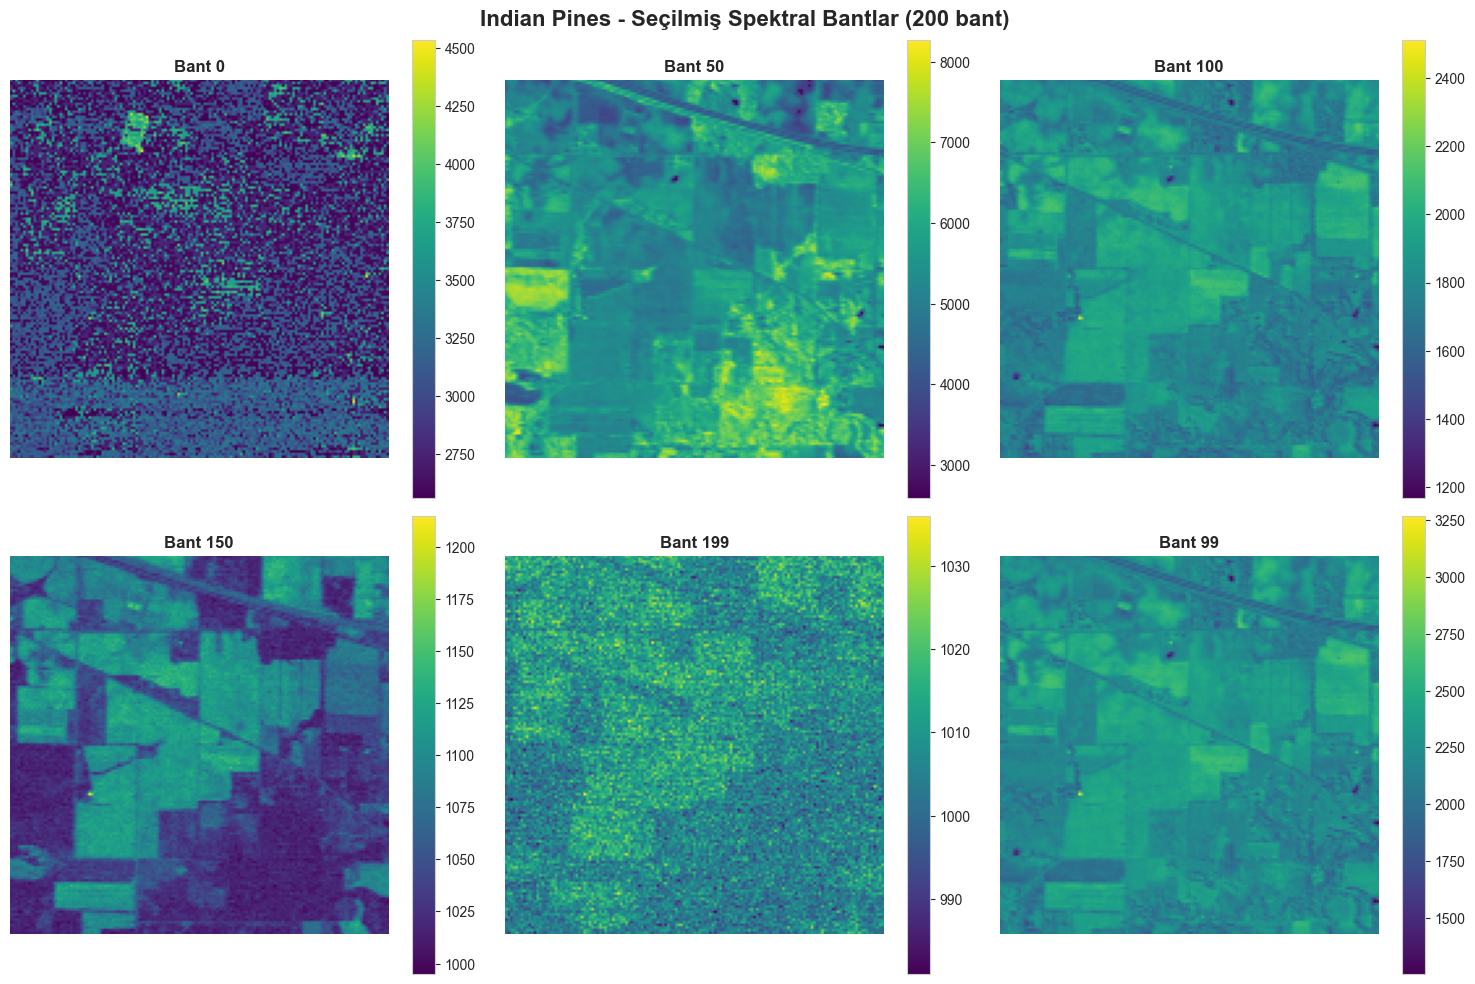

✓ Indian Pines spektral bantlar görselleştirildi.


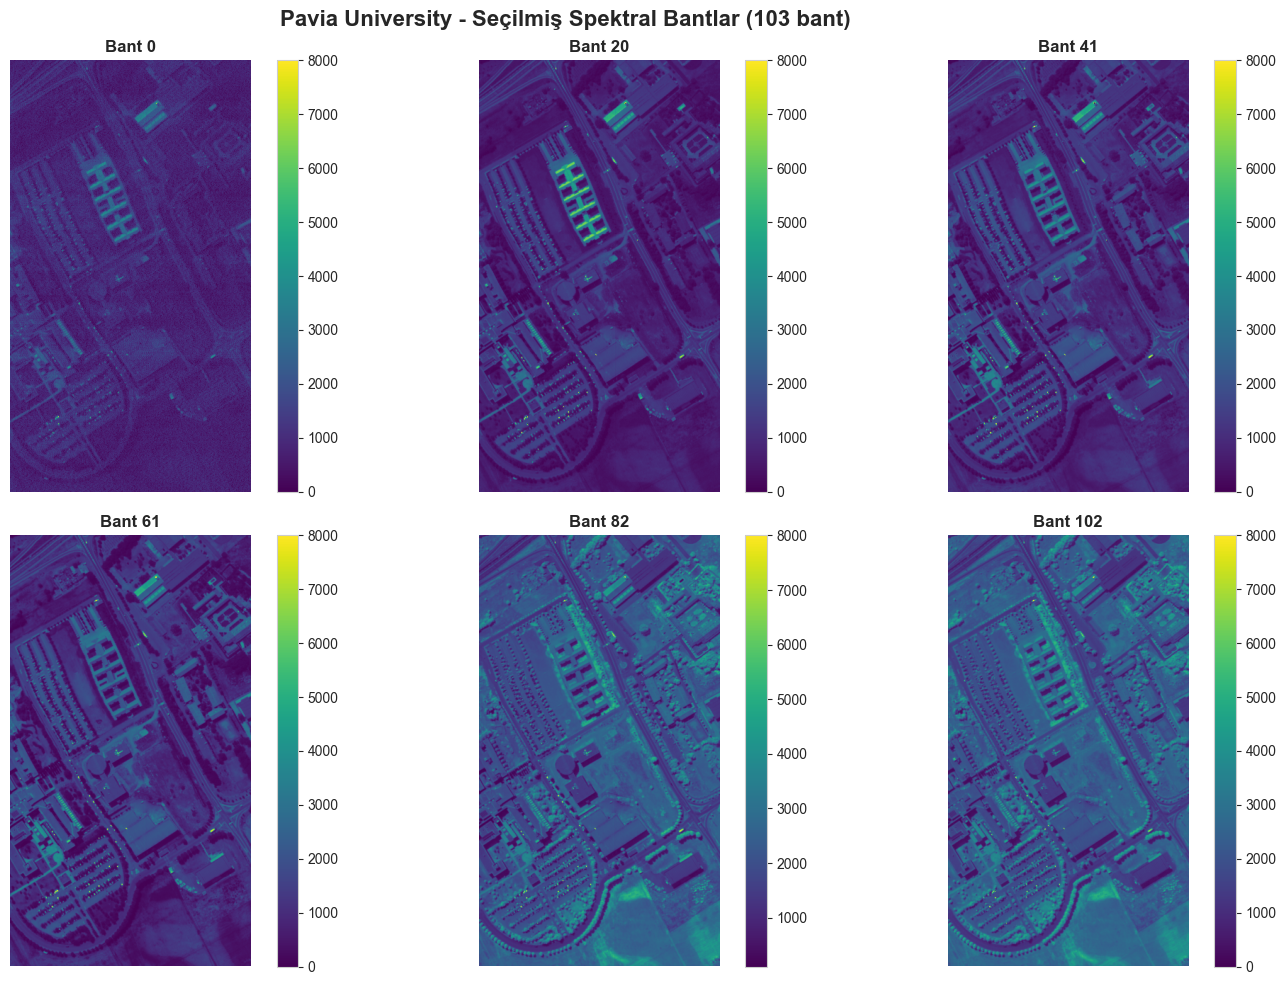

✓ Pavia University spektral bantlar görselleştirildi.


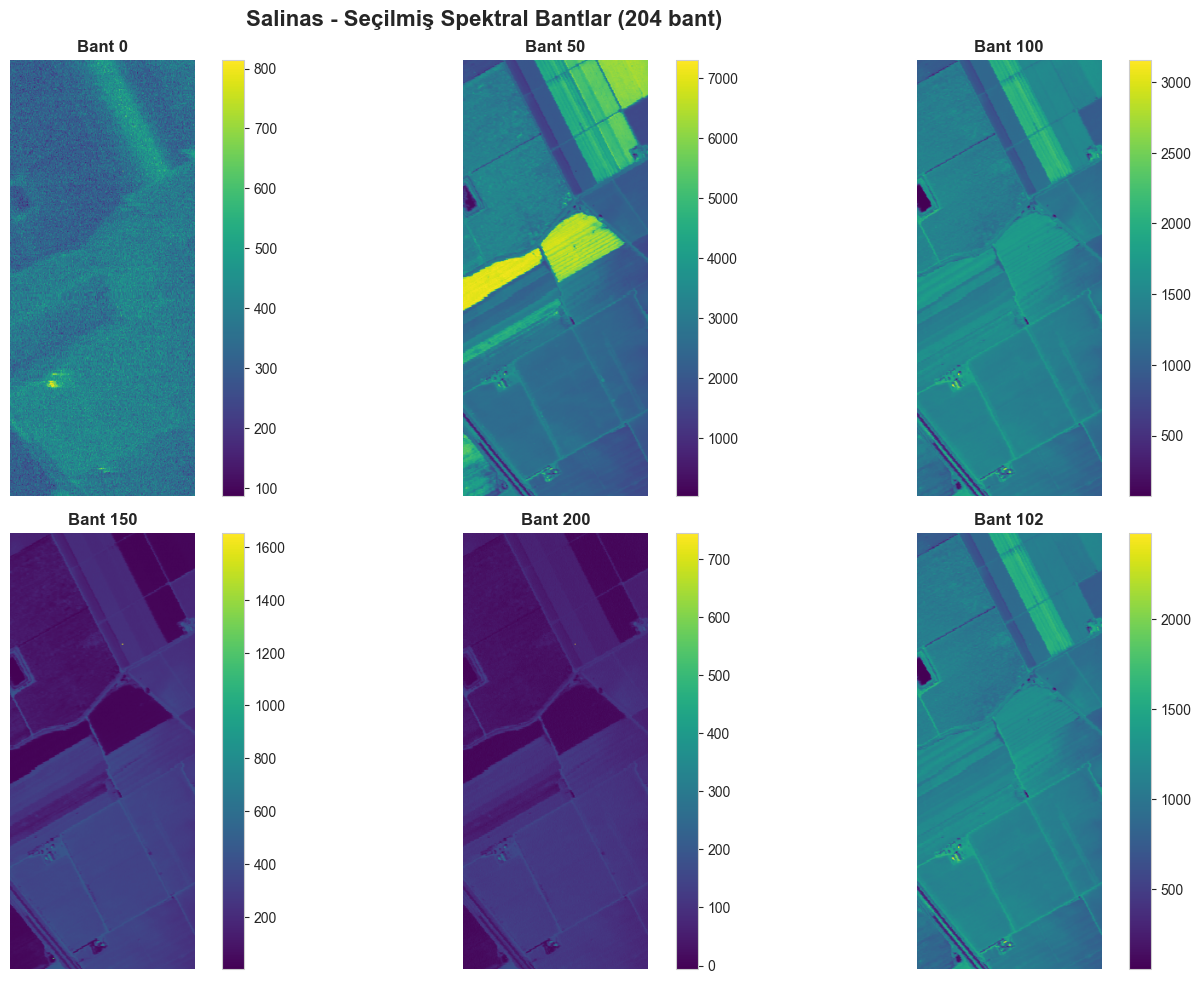

✓ Salinas spektral bantlar görselleştirildi.


In [12]:
# Tüm datasetlerin spektral bantlarını görselleştir

# ============================================================
# 1. INDIAN PINES
# ============================================================
if 'indian_img' in locals():
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Indian Pines - Seçilmiş Spektral Bantlar (200 bant)', fontsize=16, fontweight='bold')
    
    # Farklı bant indeksleri seç
    band_indices = [0, 50, 100, 150, 199, 99]
    
    for idx, ax in enumerate(axes.flat):
        band = band_indices[idx]
        im = ax.imshow(indian_img[:, :, band], cmap='viridis')
        ax.set_title(f'Bant {band}', fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()
    print("✓ Indian Pines spektral bantlar görselleştirildi.")

# ============================================================
# 2. PAVIA UNIVERSITY
# ============================================================
if 'pavia_img' in locals():
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Pavia University - Seçilmiş Spektral Bantlar (103 bant)', fontsize=16, fontweight='bold')
    
    # Farklı bant indeksleri seç (103 bant olduğu için uyarlandı)
    num_bands = pavia_img.shape[2]
    band_indices = [0, int(num_bands * 0.2), int(num_bands * 0.4), int(num_bands * 0.6), int(num_bands * 0.8), num_bands - 1]
    
    for idx, ax in enumerate(axes.flat):
        band = band_indices[idx]
        im = ax.imshow(pavia_img[:, :, band], cmap='viridis')
        ax.set_title(f'Bant {band}', fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()
    print("✓ Pavia University spektral bantlar görselleştirildi.")

# ============================================================
# 3. SALINAS
# ============================================================
if 'salinas_img' in locals():
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Salinas - Seçilmiş Spektral Bantlar (204 bant)', fontsize=16, fontweight='bold')
    
    # Farklı bant indeksleri seç
    band_indices = [0, 50, 100, 150, 200, 102]
    
    for idx, ax in enumerate(axes.flat):
        band = band_indices[idx]
        im = ax.imshow(salinas_img[:, :, band], cmap='viridis')
        ax.set_title(f'Bant {band}', fontweight='bold')
        ax.axis('off')
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()
    print("✓ Salinas spektral bantlar görselleştirildi.")

## 6. Sınıf Dağılımı

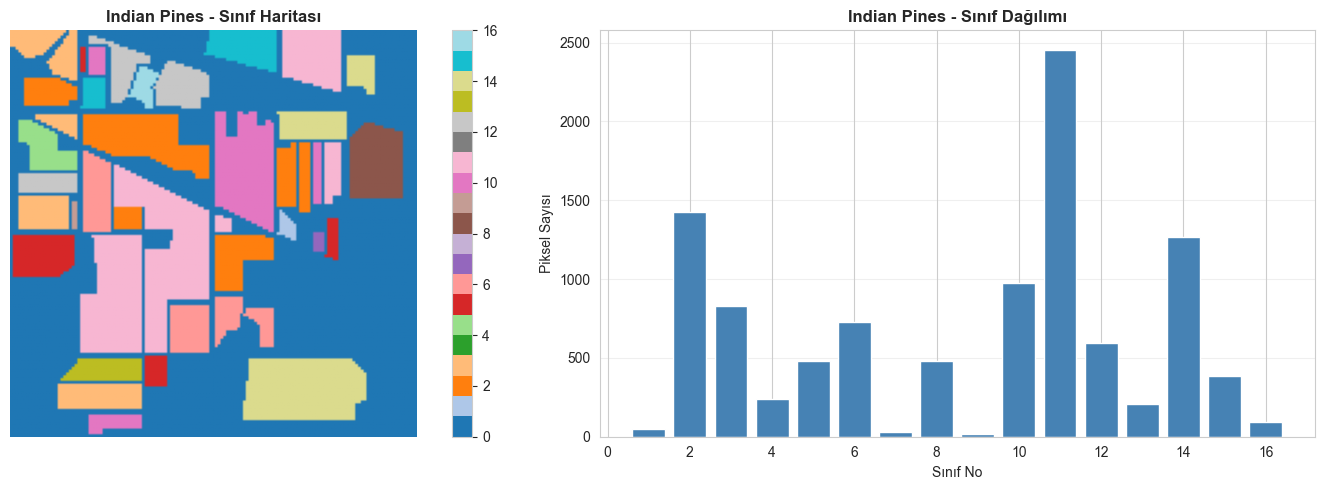

✓ Indian Pines sınıf dağılımı görselleştirildi.


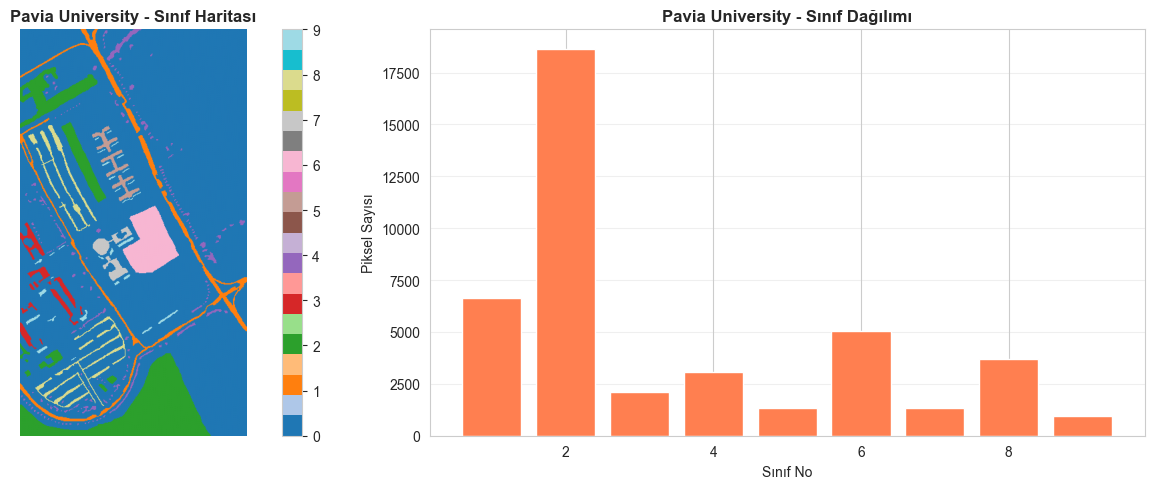

✓ Pavia University sınıf dağılımı görselleştirildi.


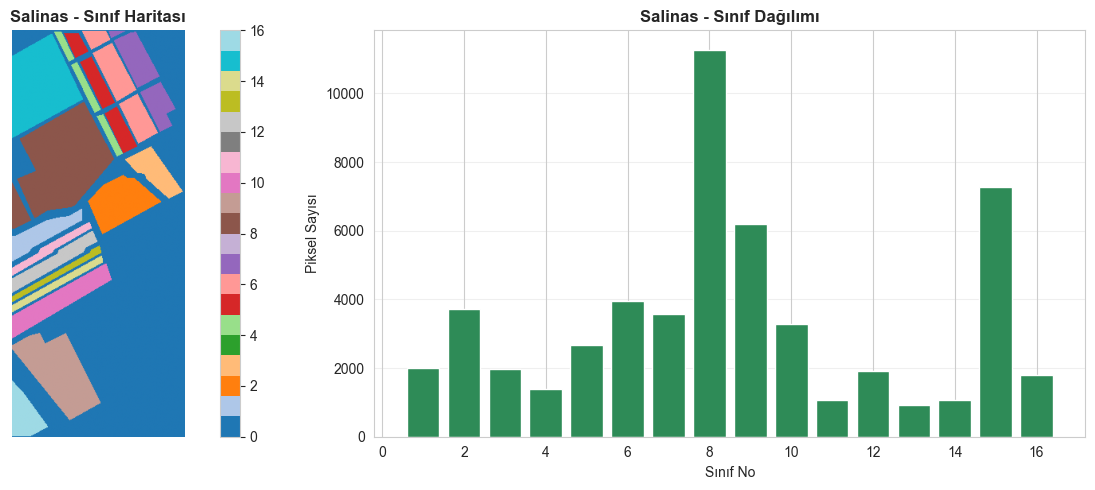

✓ Salinas sınıf dağılımı görselleştirildi.


In [13]:
# Tüm datasetlerin sınıf dağılımını görselleştir

# ============================================================
# 1. INDIAN PINES
# ============================================================
if 'indian_gt' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Sınıf haritası
    im1 = axes[0].imshow(indian_gt, cmap='tab20')
    axes[0].set_title('Indian Pines - Sınıf Haritası', fontweight='bold', fontsize=12)
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0])
    
    # Sınıf sayısı
    unique_classes = np.unique(indian_gt)
    class_counts = [np.sum(indian_gt == c) for c in unique_classes[unique_classes > 0]]
    
    axes[1].bar(range(1, len(class_counts) + 1), class_counts, color='steelblue')
    axes[1].set_title('Indian Pines - Sınıf Dağılımı', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Sınıf No')
    axes[1].set_ylabel('Piksel Sayısı')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("✓ Indian Pines sınıf dağılımı görselleştirildi.")

# ============================================================
# 2. PAVIA UNIVERSITY
# ============================================================
if 'pavia_gt' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Sınıf haritası
    im1 = axes[0].imshow(pavia_gt, cmap='tab20')
    axes[0].set_title('Pavia University - Sınıf Haritası', fontweight='bold', fontsize=12)
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0])
    
    # Sınıf sayısı
    unique_classes = np.unique(pavia_gt)
    class_counts = [np.sum(pavia_gt == c) for c in unique_classes[unique_classes > 0]]
    
    axes[1].bar(range(1, len(class_counts) + 1), class_counts, color='coral')
    axes[1].set_title('Pavia University - Sınıf Dağılımı', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Sınıf No')
    axes[1].set_ylabel('Piksel Sayısı')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("✓ Pavia University sınıf dağılımı görselleştirildi.")

# ============================================================
# 3. SALINAS
# ============================================================
if 'salinas_gt' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Sınıf haritası
    im1 = axes[0].imshow(salinas_gt, cmap='tab20')
    axes[0].set_title('Salinas - Sınıf Haritası', fontweight='bold', fontsize=12)
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0])
    
    # Sınıf sayısı
    unique_classes = np.unique(salinas_gt)
    class_counts = [np.sum(salinas_gt == c) for c in unique_classes[unique_classes > 0]]
    
    axes[1].bar(range(1, len(class_counts) + 1), class_counts, color='seagreen')
    axes[1].set_title('Salinas - Sınıf Dağılımı', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Sınıf No')
    axes[1].set_ylabel('Piksel Sayısı')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("✓ Salinas sınıf dağılımı görselleştirildi.")

## 7. Veri Kaydetme ve Export

In [14]:
# Yüklü veri setlerini NumPy dosyaları olarak kaydet (hızlı erişim için)
datasets = {}

if 'indian_img' in locals():
    np.save(os.path.join(PROCESSED_DIR, 'indian_pines_img.npy'), indian_img)
    np.save(os.path.join(PROCESSED_DIR, 'indian_pines_gt.npy'), indian_gt)
    datasets['Indian Pines'] = {
        'shape': indian_img.shape,
        'saved': True
    }
    print("✓ Indian Pines verisi kaydedildi")

if 'pavia_img' in locals():
    np.save(os.path.join(PROCESSED_DIR, 'pavia_university_img.npy'), pavia_img)
    np.save(os.path.join(PROCESSED_DIR, 'pavia_university_gt.npy'), pavia_gt)
    datasets['Pavia University'] = {
        'shape': pavia_img.shape,
        'saved': True
    }
    print("✓ Pavia University verisi kaydedildi")

if 'salinas_img' in locals():
    np.save(os.path.join(PROCESSED_DIR, 'salinas_img.npy'), salinas_img)
    np.save(os.path.join(PROCESSED_DIR, 'salinas_gt.npy'), salinas_gt)
    datasets['Salinas'] = {
        'shape': salinas_img.shape,
        'saved': True
    }
    print("✓ Salinas verisi kaydedildi")

print(f"\n✓ Tüm veriler {PROCESSED_DIR} klasöründe başarıyla kaydedildi.")


✓ Indian Pines verisi kaydedildi
✓ Pavia University verisi kaydedildi
✓ Salinas verisi kaydedildi

✓ Tüm veriler /Users/tanerciyas/workspace/github.com/ghurstird/hyperspectral_classification/notebooks/datasets/processed klasöründe başarıyla kaydedildi.
